In [4]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [5]:



def greeks(S: float, K: float, T: float, r:float, sigma: float, option_type: str = 'call'):
    """ 
    Compute all five Greeks for a European option

    Delta: sensitivity to spot price move
    Gamma: rate of change of delta (same for call and put)
    Theta: daily time decay (divided by 365)
    Vega: sensitivity to 1% move in volatility
    Rho: sensitivity to 1% move in interest rates
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Gamma and Vega are the same for calls and puts
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100 # Vega per 1% change in volatility

    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    if option_type == 'put':
        delta = norm.cdf(d1) - 1
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    return {
        'delta': delta,
        'gamma': gamma,
        'theta': theta, 
        'vega': vega, 
        'rho': rho
    }

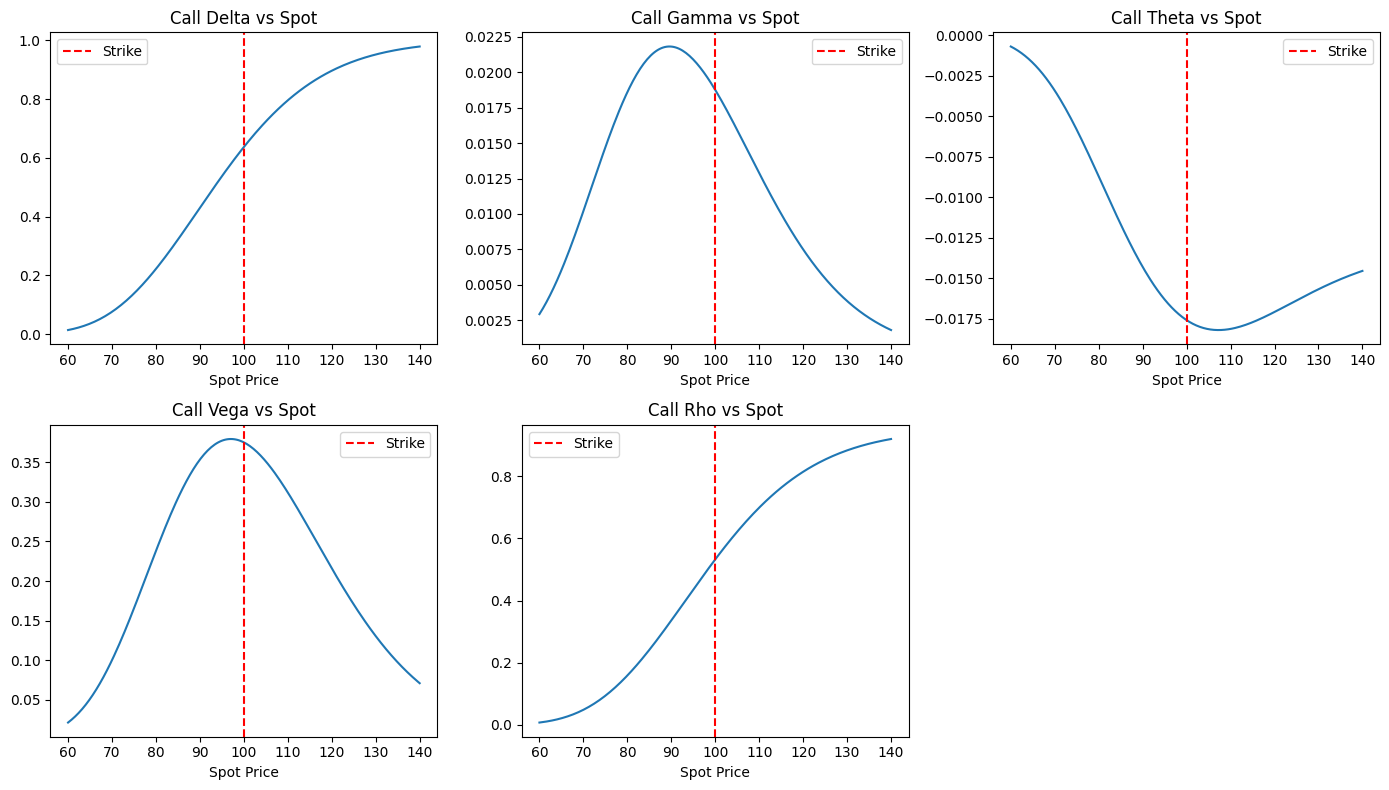

In [6]:
spots = np.linspace(60, 140, 200)
K, T, r, sigma = 100, 1, 0.05, 0.20

greek_values = [greeks(S, K, T, r, sigma, 'call') for S in spots]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

metrics = ['delta', 'gamma', 'theta', 'vega', 'rho']
for i, metric in enumerate(metrics):
    values = [g[metric] for g in greek_values]
    axes[i].plot(spots, values)
    axes[i].set_title(f"Call {metric.capitalize()} vs Spot")
    axes[i].axvline(K, color='red', linestyle='--', label='Strike')
    axes[i].set_xlabel("Spot Price")
    axes[i].legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.show()